# Single layer testing

This notebook tests the backend setup for a single homogeneous layer with an
isotropic and a Rayleigh phase function.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg
from eradiate.xarray import unstack_mdistant_grid

import eradiate_disort as ed
from eradiate_disort.util import disort_reshape_pplane

eradiate.set_mode("ckd")

# Experiment parameters
SZA = 30.0
PHASES = ["isotropic", "rayleigh"]
ZENITHS = np.arange(-75.0, 76.0, 1.0)
SRF = {"type": "delta", "wavelengths": [550.0]}
SPP = 1_000

In [3]:
# Dev-specific setup, hidden from notebook output

from eradiate_disort.testing import TestMode

plt = TestMode.plt()
_base_spp = TestMode.spp(tutorial=1_000, test=10_000)
SPP = _base_spp // 16 if eradiate.get_mode().is_ckd else _base_spp

In [4]:
results = {}

for phase in PHASES:
    # Mitsuba backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 1.0 * ureg.km,
            "zgrid": np.linspace(0, 1, 2) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.0},
        atmosphere={"type": "homogeneous", "phase": {"type": phase}},
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "mdistant",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
            "srf": SRF,
        },
    )
    mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    # DISORT backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 1.0 * ureg.km,
            "zgrid": np.linspace(0, 1, 2) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.0},
        atmosphere={"type": "homogeneous", "phase": {"type": phase}},
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "disort",
            "construct": "hplane",
            "azimuth": 0.0,
            "zeniths": ZENITHS,
            "srf": SRF,
        },
    )
    disort = disort_reshape_pplane(ed.DisortBackend().run(exp).sel(z=1000.0))

    results[phase] = {"mitsuba": mitsuba, "disort": disort}

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

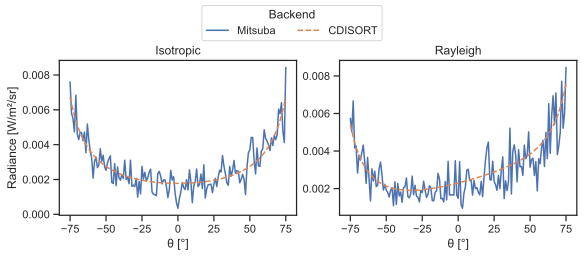

In [5]:
def plot(results):
    fig, axs = plt.subplots(1, len(results), figsize=(8, 3.5), layout="constrained")

    for k, phase in enumerate(results.keys()):
        ax = axs[k]
        result = results[phase]

        ax.plot(
            result["mitsuba"]["vza"],
            result["mitsuba"],
            label="Mitsuba" if k == 0 else None,
        )
        ax.plot(
            result["disort"]["vza"],
            result["disort"],
            label="CDISORT" if k == 0 else None,
            ls="--",
        )

        ax.set_xlabel("θ [°]")
        ax.set_ylabel("Radiance [W/m²/sr]" if k == 0 else None)
        ax.set_title(phase.title())

    fig.legend(title="Backend", loc="outside upper center", ncol=2)

    return fig, axs


plot(results)
plt.show()
plt.close()

## Full viewing grid

The comparison is repeated over a full azimuth/zenith grid for the Rayleigh
phase function.

In [6]:
results_grid = {}

for phase in ["rayleigh"]:
    # Mitsuba backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 1.0 * ureg.km,
            "zgrid": np.linspace(0, 1, 2) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.0},
        atmosphere={"type": "homogeneous", "phase": {"type": phase}},
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "mdistant",
            "construct": "grid",
            "azimuths": np.arange(0, 360, 10),
            "zeniths": np.arange(0, 75.1, 5),
        },
    )
    mitsuba = unstack_mdistant_grid(eradiate.run(exp, spp=SPP)["radiance"]).squeeze()

    # DISORT backend
    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 1.0 * ureg.km,
            "zgrid": np.linspace(0, 1, 2) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.0},
        atmosphere={"type": "homogeneous", "phase": {"type": phase}},
        illumination={"type": "directional", "zenith": SZA, "azimuth": 0.0},
        measures={
            "type": "disort",
            "construct": "grid",
            "azimuths": np.arange(0, 360, 10),
            "zeniths": np.arange(0, 75.1, 5),
        },
    )
    disort = (
        ed.DisortBackend().run(exp)["measure/uu"].sel(z=1000.0).squeeze().sortby("vza")
    )

    results_grid[phase] = {"mitsuba": mitsuba, "disort": disort}

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

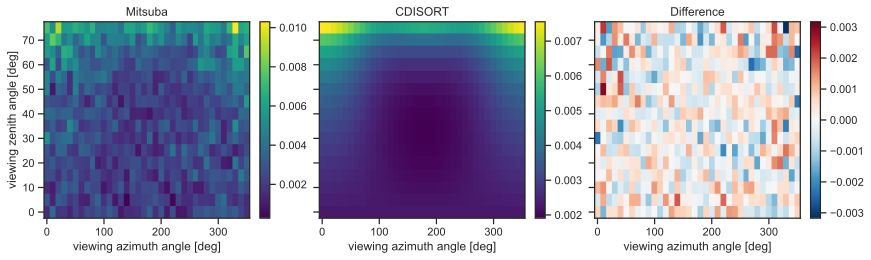

In [7]:
def plot(results):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained", sharey=True)

    mitsuba = results["rayleigh"]["mitsuba"]
    disort = results["rayleigh"]["disort"]

    ax = axs[0]
    mitsuba.plot.imshow(ax=ax, cbar_kwargs={"label": None})
    ax.set_title("Mitsuba")

    ax = axs[1]
    disort.plot.imshow(ax=ax, cbar_kwargs={"label": None})
    ax.set_title("CDISORT")
    ax.set_ylabel(None)

    ax = axs[2]
    (
        disort.assign_coords({k: mitsuba[k] for k in ["vza", "vaa"]}) - mitsuba
    ).plot.imshow(ax=ax)
    ax.set_title("Difference")
    ax.set_ylabel(None)

    return fig, axs


plot(results_grid)
plt.show()
plt.close()